# Lecture 04 — Model Evaluation, Selection & ML Pipelines

**Learning objectives**

- Distinguish training error, validation error, test error and the true generalization error, and know what each estimates.
- Implement $k$-fold cross-validation from scratch and reproduce `cross_val_score`.
- Choose the right splitting scheme: stratified, grouped, and time-series splits.
- Diagnose under- and over-fitting with learning curves and validation curves (bias–variance view).
- Tune hyperparameters with grid and random search, and estimate the performance of the *whole tuning procedure* with nested CV.
- Recognize and prevent **data leakage** using `Pipeline`.
- Build realistic preprocessing with `ColumnTransformer` (imputation, scaling, one-hot encoding) on mixed-type data.
- Compare two models statistically and understand the caveats (dependent folds, McNemar's test).

**Prerequisites**: `02_*.ipynb` (linear regression, regularization), `03_logistic_regression_and_classification.ipynb` (logistic regression, classification metrics).

**Contents**

1. Generalization and the train / validation / test protocol
2. $k$-fold cross-validation from scratch
3. Splitting strategies: stratified, grouped, time series
4. Bias–variance diagnosis: validation curves and learning curves
5. Hyperparameter search: grid, random, and nested CV
6. Data leakage and `Pipeline`
7. Preprocessing mixed data with `ColumnTransformer`
8. Statistical comparison of models
9. Pitfalls & practical tips
10. Exercises
11. Summary & further reading

In [1]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.exceptions import ConvergenceWarning
from sklearn.datasets import load_breast_cancer, load_digits, load_diabetes, make_classification, make_regression
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit,
                                     cross_val_score, cross_validate, learning_curve, validation_curve,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)
rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=4, suppress=True)

## 1. Generalization and the train / validation / test protocol

Let $\mathcal{D}$ be the (unknown) data distribution and $\ell$ a loss. For a model $\hat f$ learned from a training set $S$ of size $n$, the quantity we care about is the **generalization (test) error**

$$
R(\hat f) = \mathbb{E}_{(\mathbf{x},y)\sim\mathcal{D}}\big[\ell(\hat f(\mathbf{x}), y)\big],
$$

whereas we can only compute the **empirical (training) risk** $\hat R_S(\hat f) = \frac1n\sum_{i\in S}\ell(\hat f(\mathbf{x}_i), y_i)$. Because $\hat f$ was chosen *using* $S$, $\hat R_S(\hat f)$ is **optimistically biased**; the gap $R - \hat R_S$ grows with model flexibility.

An error estimate is unbiased only on data that played **no role** in any decision about the model. Hence the classical three-way protocol:

| split | used for | estimate is ... |
|---|---|---|
| **training** | fitting parameters $\mathbf{w}$ | optimistic |
| **validation** | choosing hyperparameters / models / thresholds | optimistic once used for selection ("winner's curse") |
| **test** | one final, untouched estimate | unbiased for the selected model |

With a hold-out test set of size $m$ and 0–1 loss, the test error is a binomial proportion with standard error $\sqrt{\hat R(1-\hat R)/m}$: with $m=100$ and $\hat R = 0.1$ this is $\pm 3\%$ — small test sets give **noisy** estimates. Cross-validation reuses data to reduce this variance.

train 300, validation 150, test 150


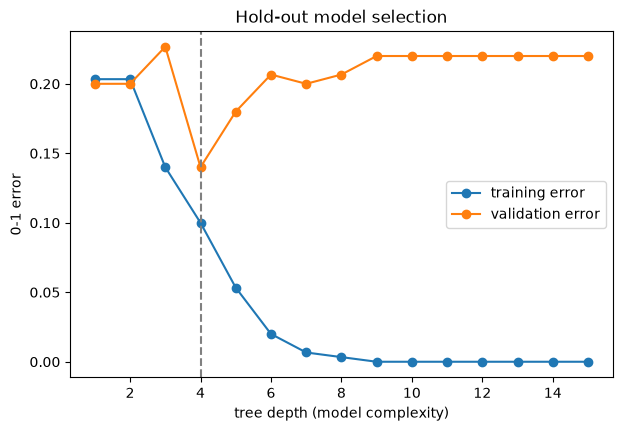

selected depth=4: min validation error=0.140 (optimistic), test error=0.153 +/- 0.029 (1 s.e.)


In [2]:
# Training error keeps falling with model complexity; validation error is U-shaped.
X, y = make_classification(n_samples=600, n_features=20, n_informative=5, flip_y=0.08, random_state=0)
X_trval, X_test, y_trval, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)
X_tr, X_val, y_tr, y_val = train_test_split(X_trval, y_trval, test_size=1/3, stratify=y_trval, random_state=0)
print(f"train {len(y_tr)}, validation {len(y_val)}, test {len(y_test)}")

depths = range(1, 16)
tr_err, val_err = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_tr, y_tr)
    tr_err.append(1 - t.score(X_tr, y_tr)); val_err.append(1 - t.score(X_val, y_val))
best_d = depths[int(np.argmin(val_err))]
final = DecisionTreeClassifier(max_depth=best_d, random_state=0).fit(X_trval, y_trval)
test_err = 1 - final.score(X_test, y_test)

plt.plot(depths, tr_err, "o-", label="training error")
plt.plot(depths, val_err, "o-", label="validation error")
plt.axvline(best_d, ls="--", c="gray")
plt.xlabel("tree depth (model complexity)"); plt.ylabel("0-1 error"); plt.legend()
plt.title("Hold-out model selection"); plt.show()
se = np.sqrt(test_err * (1 - test_err) / len(y_test))
print(f"selected depth={best_d}: min validation error={min(val_err):.3f} (optimistic), "
      f"test error={test_err:.3f} +/- {se:.3f} (1 s.e.)")

## 2. $k$-fold cross-validation from scratch

Partition the indices into $k$ disjoint folds $F_1,\dots,F_k$ of (nearly) equal size. For each $j$, train on all folds except $F_j$ and evaluate on $F_j$:

$$
\widehat{\text{CV}}_k = \frac1k\sum_{j=1}^k \hat R_{F_j}\big(\hat f^{(-j)}\big),
\qquad
\hat R_{F_j}(f) = \frac{1}{|F_j|}\sum_{i\in F_j}\ell\big(f(\mathbf{x}_i), y_i\big).
$$

Every sample is used for validation exactly once and for training $k-1$ times.

**What does CV estimate?** The expected error of a model trained on $\frac{k-1}{k}n$ points — slightly **pessimistic** for the final model trained on all $n$ points (bias decreases with $k$). Its **variance** is subtle: the $k$ fold estimates are *correlated* (training sets overlap), so the naive standard error $s/\sqrt{k}$ **underestimates** the true uncertainty; there is no unbiased estimator of the variance of $k$-fold CV (Bengio & Grandvalet, 2004).

**Choice of $k$.** $k=5$ or $10$ is a good bias/variance/computation compromise. $k=n$ (**leave-one-out**, LOO) is nearly unbiased but high-variance and costly — except for linear smoothers, where the LOO error has a closed form: $\frac1n\sum_i\big(\frac{y_i-\hat y_i}{1-H_{ii}}\big)^2$ with hat matrix $H$.

**Repeated CV** (different random partitions) averages out partition noise.

In [3]:
def kfold_indices(n, k, shuffle=True, seed=0):
    # Return a list of (train_idx, val_idx) pairs; fold sizes differ by at most one.
    idx = np.random.default_rng(seed).permutation(n) if shuffle else np.arange(n)
    fold_sizes = np.full(k, n // k); fold_sizes[: n % k] += 1
    folds, start = [], 0
    for size in fold_sizes:
        folds.append(idx[start:start + size]); start += size
    return [(np.concatenate(folds[:j] + folds[j + 1:]), folds[j]) for j in range(k)]

def cross_val_scratch(model, X, y, splits, score_fn):
    scores = []
    for tr, va in splits:
        m = clone(model).fit(X[tr], y[tr])          # fresh, unfitted copy per fold
        scores.append(score_fn(y[va], m.predict(X[va])))
    return np.array(scores)

bc = load_breast_cancer()
Xb, yb = bc.data, bc.target
model = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000))
acc = lambda yt, yp: np.mean(yt == yp)

splits = kfold_indices(len(yb), k=5, seed=0)
ours = cross_val_scratch(model, Xb, yb, splits, acc)
# Pass exactly the same splits to sklearn -> identical numbers
theirs = cross_val_score(model, Xb, yb, cv=splits, scoring="accuracy")
print("scratch folds:", ours.round(4), " mean", ours.mean().round(4))
print("sklearn folds:", theirs.round(4), " mean", theirs.mean().round(4))
print("identical:", np.allclose(ours, theirs))

scratch folds: [0.9912 0.9737 0.9825 0.9737 0.9735]  mean 0.9789
sklearn folds: [0.9912 0.9737 0.9825 0.9737 0.9735]  mean 0.9789
identical: True


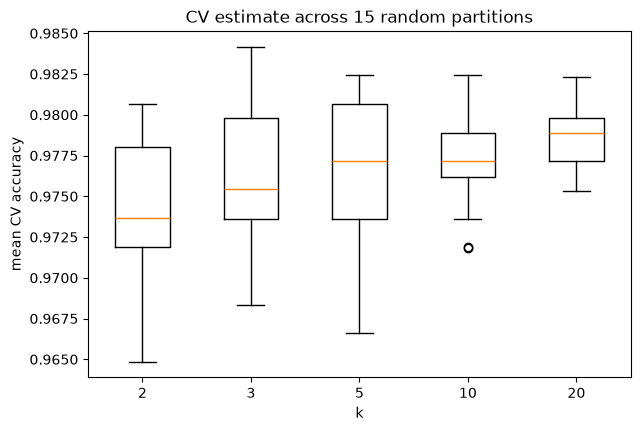

k= 2: mean over partitions=0.9741  sd across partitions=0.0044
k= 3: mean over partitions=0.9766  sd across partitions=0.0045
k= 5: mean over partitions=0.9767  sd across partitions=0.0044
k=10: mean over partitions=0.9771  sd across partitions=0.0029
k=20: mean over partitions=0.9787  sd across partitions=0.0019


In [4]:
# Variability of the CV estimate: depends on k and on the random partition
ks = [2, 3, 5, 10, 20]
res = {k: [cross_val_score(model, Xb, yb, cv=KFold(k, shuffle=True, random_state=s)).mean() for s in range(15)]
       for k in ks}
plt.boxplot([res[k] for k in ks], tick_labels=[str(k) for k in ks])
plt.xlabel("k"); plt.ylabel("mean CV accuracy"); plt.title("CV estimate across 15 random partitions")
plt.show()
for k in ks:
    print(f"k={k:2d}: mean over partitions={np.mean(res[k]):.4f}  sd across partitions={np.std(res[k]):.4f}")

## 3. Splitting strategies: stratified, grouped, time series

Plain $k$-fold assumes samples are **i.i.d.** and that random folds mimic the deployment setting. Three common deviations:

- **Stratified $k$-fold** keeps the class proportions in every fold (important for small or imbalanced data; reduces variance of the estimate). Default in `cross_val_score` for classifiers.
- **Group $k$-fold**: samples come in groups (several images of the same patient, several sessions per user). If the same group appears in both train and validation folds, the model can exploit group identity and the estimate is **over-optimistic**. All samples of a group must go to the same fold.
- **Time-series split** (forward chaining): train on the past, validate on the future, never the reverse. Random folds on temporally correlated data leak future information. Optionally leave a **gap** between train and validation to account for autocorrelation.

The rule: **the split must mimic how the model will be used**.

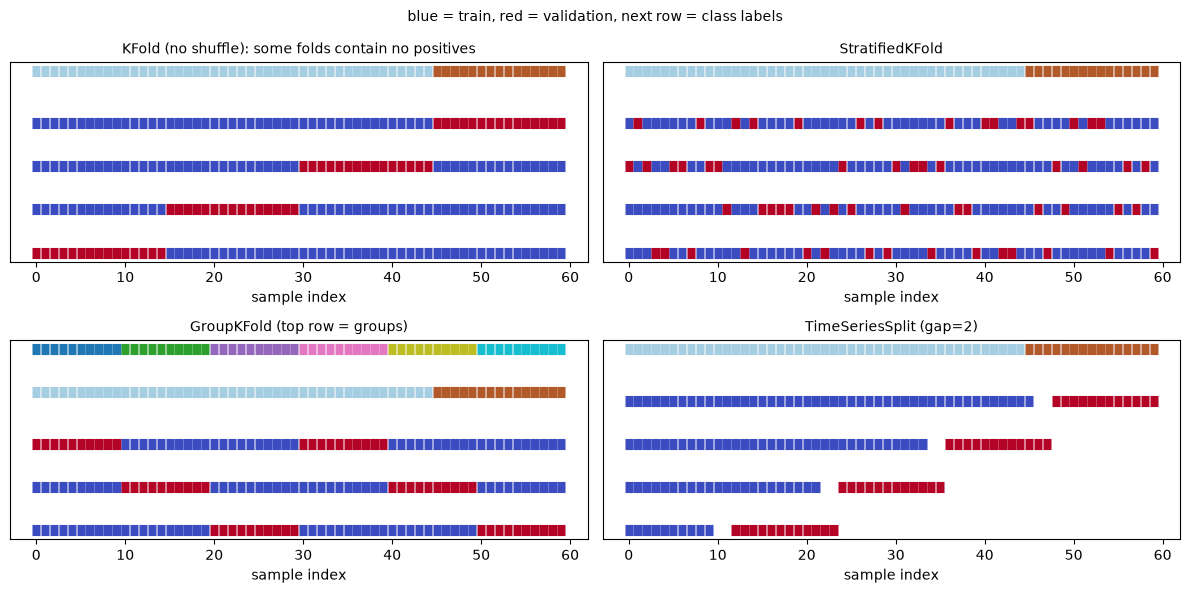

In [5]:
def plot_cv(ax, cv, X, y, groups=None, title=""):
    for j, (tr, va) in enumerate(cv.split(X, y, groups)):
        row = np.full(len(X), np.nan); row[tr] = 0; row[va] = 1
        ax.scatter(np.arange(len(X)), np.full(len(X), j), c=row, cmap="coolwarm", marker="_", lw=8, vmin=0, vmax=1)
    ax.scatter(np.arange(len(X)), np.full(len(X), j + 1.2), c=y, cmap="Paired", marker="_", lw=8)
    if groups is not None:
        ax.scatter(np.arange(len(X)), np.full(len(X), j + 2.2), c=groups, cmap="tab10", marker="_", lw=8)
    ax.set_title(title, fontsize=10); ax.set_yticks([]); ax.set_xlabel("sample index")

n = 60
y_demo = (np.arange(n) >= 45).astype(int)          # imbalanced, sorted labels
g_demo = np.repeat(np.arange(6), 10)               # 6 groups of 10
X_demo = np.zeros((n, 1))
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
plot_cv(ax[0, 0], KFold(4), X_demo, y_demo, title="KFold (no shuffle): some folds contain no positives")
plot_cv(ax[0, 1], StratifiedKFold(4, shuffle=True, random_state=0), X_demo, y_demo, title="StratifiedKFold")
plot_cv(ax[1, 0], GroupKFold(3), X_demo, y_demo, g_demo, title="GroupKFold (top row = groups)")
plot_cv(ax[1, 1], TimeSeriesSplit(4, gap=2), X_demo, y_demo, title="TimeSeriesSplit (gap=2)")
plt.suptitle("blue = train, red = validation, next row = class labels", fontsize=10)
plt.tight_layout(); plt.show()

**Demonstration: group leakage.** We simulate 40 "patients", each with 15 measurements. Every patient has an idiosyncratic feature signature, and labels are a patient-level property. A flexible model can memorize patients: random $k$-fold rewards memorization, `GroupKFold` measures generalization to **new patients**.

In [6]:
n_groups, per = 40, 15
groups = np.repeat(np.arange(n_groups), per)
patient_label = rng.integers(0, 2, n_groups)
patient_center = rng.normal(0, 2, (n_groups, 10))            # patient-specific signature (not label-related)
signal = np.outer(patient_label - 0.5, np.r_[0.6, np.zeros(9)])  # weak true signal in feature 0
Xg = patient_center[groups] + signal[groups] + rng.normal(0, 0.5, (n_groups * per, 10))
yg = patient_label[groups]

knn = KNeighborsClassifier(n_neighbors=5)
s_random = cross_val_score(knn, Xg, yg, cv=KFold(5, shuffle=True, random_state=0))
s_group = cross_val_score(knn, Xg, yg, cv=GroupKFold(5), groups=groups)
print(f"random KFold accuracy: {s_random.mean():.3f}   <- memorizes patients")
print(f"GroupKFold accuracy:   {s_group.mean():.3f}   <- honest estimate for new patients")

random KFold accuracy: 1.000   <- memorizes patients
GroupKFold accuracy:   0.525   <- honest estimate for new patients


In [7]:
# Time series: random KFold vs forward-chaining on an autocorrelated regression problem
T = 600
t = np.arange(T)
series = np.cumsum(rng.normal(0, 1, T))                      # random walk (strongly autocorrelated)
Xt = np.c_[t / T, np.sin(t / 20)]                             # features: time and a seasonal term
yt_ = series + 3 * np.sin(t / 20)
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
r2_random = cross_val_score(rf, Xt, yt_, cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
r2_ts = cross_val_score(rf, Xt, yt_, cv=TimeSeriesSplit(5), scoring="r2")
print(f"R^2 with shuffled KFold:   {r2_random.mean():.3f}  (interpolates between neighbouring time points)")
print(f"R^2 with TimeSeriesSplit:  {r2_ts.mean():.3f}  (true forecasting performance)")

R^2 with shuffled KFold:   0.984  (interpolates between neighbouring time points)
R^2 with TimeSeriesSplit:  -2.118  (true forecasting performance)


## 4. Bias–variance diagnosis: validation curves and learning curves

Recall the decomposition for squared loss (Lecture 02): with $y = f(\mathbf{x}) + \varepsilon$, $\operatorname{Var}\varepsilon = \sigma^2$,

$$
\mathbb{E}_{S,\varepsilon}\big[(y - \hat f_S(\mathbf{x}))^2\big] = \underbrace{\big(f(\mathbf{x}) - \mathbb{E}_S \hat f_S(\mathbf{x})\big)^2}_{\text{bias}^2} + \underbrace{\operatorname{Var}_S\big(\hat f_S(\mathbf{x})\big)}_{\text{variance}} + \underbrace{\sigma^2}_{\text{irreducible}}.
$$

Two diagnostic plots make this operational:

- **Validation curve**: training and CV score as a function of **one hyperparameter** (complexity). Left side (both scores low, close together) = **high bias / underfitting**; right side (training high, CV dropping, big gap) = **high variance / overfitting**.
- **Learning curve**: training and CV score as a function of **training set size** $n$.
  - High bias: both curves converge quickly to a *low* plateau; more data will **not** help — increase model capacity or add features.
  - High variance: large gap that shrinks slowly as $n$ grows; more data, regularization, or a simpler model **will** help.

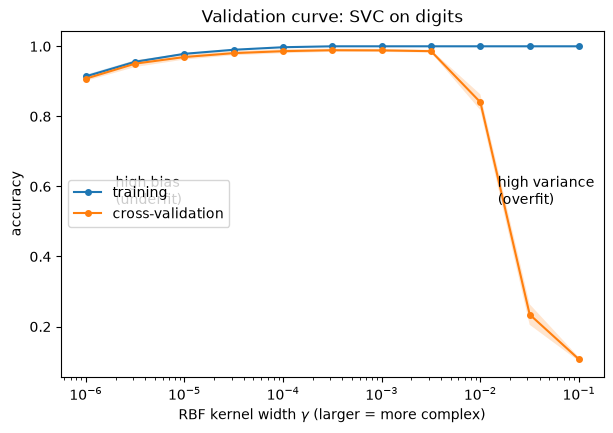

best gamma by CV: 0.00031622776601683794


In [8]:
digits = load_digits()
Xd, yd = digits.data, digits.target
gammas = np.logspace(-6, -1, 11)
tr_s, va_s = validation_curve(SVC(C=10), Xd, yd, param_name="gamma", param_range=gammas,
                              cv=StratifiedKFold(5, shuffle=True, random_state=0), n_jobs=-1)

def band(ax, x, S, label, logx=True):
    m, s = S.mean(1), S.std(1)
    (ax.semilogx if logx else ax.plot)(x, m, "o-", label=label, ms=4)
    ax.fill_between(x, m - s, m + s, alpha=0.2)

fig, ax = plt.subplots(figsize=(7, 4.5))
band(ax, gammas, tr_s, "training"); band(ax, gammas, va_s, "cross-validation")
ax.set_xlabel(r"RBF kernel width $\gamma$ (larger = more complex)"); ax.set_ylabel("accuracy")
ax.text(2e-6, 0.55, "high bias\n(underfit)"); ax.text(1.5e-2, 0.55, "high variance\n(overfit)")
ax.set_title("Validation curve: SVC on digits"); ax.legend(loc="center left"); plt.show()
print("best gamma by CV:", gammas[va_s.mean(1).argmax()])

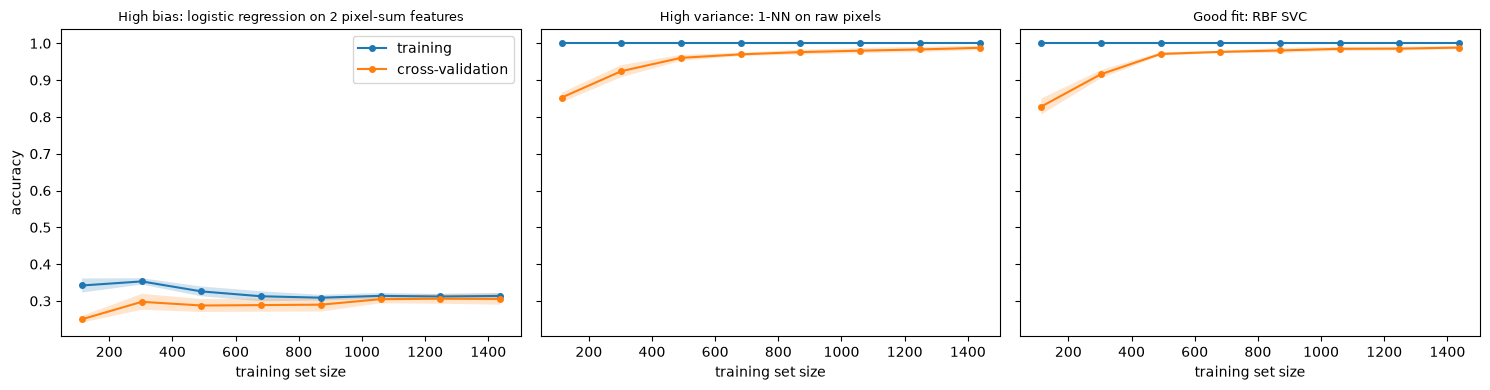

In [9]:
sizes = np.linspace(0.08, 1.0, 8)
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
configs = [
    ("High bias: logistic regression on 2 pixel-sum features", "bias"),
    ("High variance: 1-NN on raw pixels", "var"),
    ("Good fit: RBF SVC", "good"),
]
# Crude 2-feature representation (row-sums of the upper and lower image halves) -> underfits
X_crude = np.c_[Xd[:, :32].sum(1), Xd[:, 32:].sum(1)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (title, kind) in zip(axes, configs):
    if kind == "bias":
        est, Xuse = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), X_crude
    elif kind == "var":
        est, Xuse = KNeighborsClassifier(n_neighbors=1), Xd
    else:
        est, Xuse = SVC(C=10, gamma=1e-3), Xd
    n_abs, tr_lc, va_lc = learning_curve(est, Xuse, yd, train_sizes=sizes, cv=cv5, n_jobs=-1)
    band(ax, n_abs, tr_lc, "training", logx=False); band(ax, n_abs, va_lc, "cross-validation", logx=False)
    ax.set_title(title, fontsize=9); ax.set_xlabel("training set size")
axes[0].set_ylabel("accuracy"); axes[0].legend(); plt.tight_layout(); plt.show()

Reading the plots: the crude 2-feature model has training $\approx$ validation accuracy at a low level (**bias**: more data is useless). 1-NN has perfect training accuracy by construction and a gap that shrinks as data grows (**variance**). The RBF SVM achieves both high accuracy and a small gap.

## 5. Hyperparameter search: grid, random, and nested CV

**Grid search** evaluates every combination on a Cartesian grid by CV and picks the best; cost grows exponentially with the number of hyperparameters.

**Random search** (Bergstra & Bengio, 2012) samples configurations from distributions (e.g. log-uniform for $C$, $\gamma$). When only a few hyperparameters really matter ("low effective dimensionality"), random search explores many more distinct values of each important one for the same budget. Continuous distributions such as `scipy.stats.loguniform` are natural for scale parameters.

**Why nested CV?** The best CV score found by a search is the **maximum** of many noisy estimates, hence optimistically biased (selection bias / "winner's curse"; Cawley & Talbot, 2010). To estimate the performance of the *entire procedure* "tune by inner CV, then refit", wrap it in an **outer CV**:

```
for each outer fold (train_o, test_o):
    search = GridSearchCV(model, grid, cv=inner)   # tuning only sees train_o
    search.fit(X[train_o], y[train_o])
    score on X[test_o]                              # never seen by the tuning
```

Nested CV estimates the generalization error of the *learning algorithm including tuning*; it does not produce a single model. For deployment, run the search once on all data.

grid search: 25 configs, best {'svc__C': np.float64(100.0), 'svc__gamma': np.float64(0.001)}, CV acc=0.9807


random search: 25 configs, best C=12.2, gamma=0.00456, CV acc=0.9842


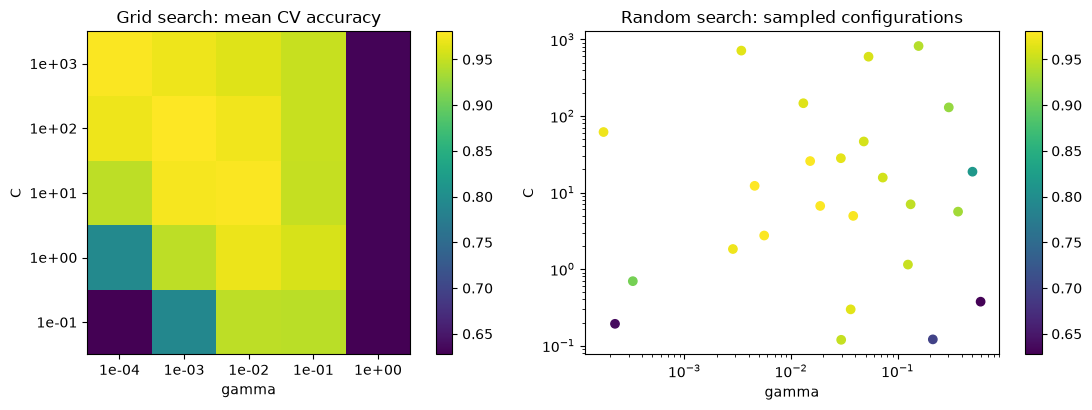

In [10]:
pipe = Pipeline([("scale", StandardScaler()), ("svc", SVC())])
param_grid = {"svc__C": np.logspace(-1, 3, 5), "svc__gamma": np.logspace(-4, 0, 5)}
grid = GridSearchCV(pipe, param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=0), n_jobs=-1).fit(Xb, yb)
print(f"grid search: {len(grid.cv_results_['params'])} configs, best {grid.best_params_}, CV acc={grid.best_score_:.4f}")

rand = RandomizedSearchCV(pipe, {"svc__C": stats.loguniform(1e-1, 1e3), "svc__gamma": stats.loguniform(1e-4, 1)},
                          n_iter=25, cv=StratifiedKFold(5, shuffle=True, random_state=0), random_state=0, n_jobs=-1).fit(Xb, yb)
print(f"random search: 25 configs, best C={rand.best_params_['svc__C']:.3g}, "
      f"gamma={rand.best_params_['svc__gamma']:.3g}, CV acc={rand.best_score_:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
scores = grid.cv_results_["mean_test_score"].reshape(5, 5)
im = ax[0].imshow(scores, origin="lower", cmap="viridis")
ax[0].set_xticks(range(5)); ax[0].set_xticklabels([f"{g:.0e}" for g in param_grid["svc__gamma"]])
ax[0].set_yticks(range(5)); ax[0].set_yticklabels([f"{c:.0e}" for c in param_grid["svc__C"]])
ax[0].set_xlabel("gamma"); ax[0].set_ylabel("C"); ax[0].set_title("Grid search: mean CV accuracy")
plt.colorbar(im, ax=ax[0])
cr = rand.cv_results_
sc_ = ax[1].scatter(cr["param_svc__gamma"].astype(float), cr["param_svc__C"].astype(float),
                    c=cr["mean_test_score"], cmap="viridis", vmin=scores.min(), vmax=scores.max())
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_xlabel("gamma"); ax[1].set_ylabel("C")
ax[1].set_title("Random search: sampled configurations"); plt.colorbar(sc_, ax=ax[1])
plt.tight_layout(); plt.show()

In [11]:
# Selection bias made visible: pure-noise labels, many candidate models.
# The best CV score is far above 50% chance, while nested CV correctly reports ~50%.
Xn = rng.normal(size=(120, 50))
yn = rng.integers(0, 2, 120)
noise_pipe = Pipeline([("scale", StandardScaler()), ("svc", SVC())])
noise_grid = {"svc__C": np.logspace(-2, 3, 8), "svc__gamma": np.logspace(-4, 1, 8)}
inner = StratifiedKFold(5, shuffle=True, random_state=1)
outer = StratifiedKFold(5, shuffle=True, random_state=2)

gs = GridSearchCV(noise_pipe, noise_grid, cv=inner, n_jobs=-1).fit(Xn, yn)
nested = cross_val_score(GridSearchCV(noise_pipe, noise_grid, cv=inner, n_jobs=-1), Xn, yn, cv=outer)
print(f"best (non-nested) CV accuracy over 64 configs: {gs.best_score_:.3f}   <- optimistic")
print(f"nested CV accuracy:                             {nested.mean():.3f}   <- honest (chance = 0.5)")

# Nested CV on the real problem
nested_bc = cross_val_score(GridSearchCV(pipe, param_grid, cv=inner, n_jobs=-1), Xb, yb, cv=outer)
print(f"breast cancer: best inner CV={grid.best_score_:.4f}, nested CV={nested_bc.mean():.4f} +/- {nested_bc.std():.4f}")

best (non-nested) CV accuracy over 64 configs: 0.517   <- optimistic
nested CV accuracy:                             0.467   <- honest (chance = 0.5)


breast cancer: best inner CV=0.9807, nested CV=0.9737 +/- 0.0235


## 6. Data leakage and `Pipeline`

**Leakage** = information from the validation/test data influences training, so the estimate no longer reflects deployment. Classic sources:

1. **Preprocessing fitted on the full data** before splitting (scaler means/variances, imputation values, PCA, target encoding).
2. **Supervised feature selection** on the full data — the most dangerous kind, because it uses the labels of the validation folds.
3. **Resampling / oversampling** before the split (duplicated minority points end up in both train and validation).
4. **Group / temporal leakage** (Section 3), and features that are proxies of the target (e.g. "treatment given" when predicting disease).

Scalers leak only mildly (unsupervised, low-dimensional statistics), but supervised selection can turn **pure noise** into seemingly excellent accuracy (ESL §7.10.2, "the wrong and the right way to do cross-validation").

The remedy is to treat **every data-dependent step as part of the model**: wrap them in a `Pipeline`, which is re-fitted inside each CV fold on the training part only.

In [12]:
# ESL 7.10.2 experiment: n=100 samples, p=5000 pure-noise features, random labels.
Xl = rng.normal(size=(100, 5000))
yl = rng.integers(0, 2, 100)
cv = StratifiedKFold(5, shuffle=True, random_state=0)

# WRONG: select the 20 features most correlated with y on ALL data, then cross-validate
selector = SelectKBest(f_classif, k=20).fit(Xl, yl)
X_sel = selector.transform(Xl)
leaky = cross_val_score(LogisticRegression(max_iter=1000), X_sel, yl, cv=cv)

# ALSO WRONG (milder): scaler fitted on all data
X_scaled_all = StandardScaler().fit_transform(Xl)

# RIGHT: selection (and scaling) inside the pipeline -> refitted within each training fold
correct_pipe = Pipeline([("scale", StandardScaler()), ("select", SelectKBest(f_classif, k=20)),
                         ("clf", LogisticRegression(max_iter=1000))])
correct = cross_val_score(correct_pipe, Xl, yl, cv=cv)
print(f"leaky feature selection outside CV: accuracy = {leaky.mean():.3f}  (labels are random!)")
print(f"selection inside Pipeline:          accuracy = {correct.mean():.3f}  (chance level, as it should be)")

leaky feature selection outside CV: accuracy = 0.820  (labels are random!)
selection inside Pipeline:          accuracy = 0.350  (chance level, as it should be)


In [13]:
# Leakage from preprocessing statistics: mean imputation fitted on all data vs inside the pipeline.
# The effect is usually small for scalers/imputers, but it is a bias nonetheless. We quantify it
# on a regression problem where missingness is informative.
Xr, yr = make_regression(n_samples=200, n_features=10, n_informative=5, noise=20, random_state=0)
Xr_miss = Xr.copy()
mask = rng.random(Xr.shape) < 0.3
Xr_miss[mask] = np.nan

def leak_vs_pipe(seed):
    cvr = KFold(5, shuffle=True, random_state=seed)
    X_imp_all = SimpleImputer().fit_transform(Xr_miss)
    X_imp_all = StandardScaler().fit_transform(X_imp_all)
    a = cross_val_score(Ridge(1.0), X_imp_all, yr, cv=cvr, scoring="r2").mean()
    b = cross_val_score(make_pipeline(SimpleImputer(), StandardScaler(), Ridge(1.0)), Xr_miss, yr, cv=cvr, scoring="r2").mean()
    return a, b
vals = np.array([leak_vs_pipe(s) for s in range(20)])
print(f"R^2 imputer+scaler fitted on all data: {vals[:, 0].mean():.4f}")
print(f"R^2 imputer+scaler inside Pipeline:    {vals[:, 1].mean():.4f}")
print(f"(mild) optimistic difference: {np.mean(vals[:, 0] - vals[:, 1]):+.4f}")

R^2 imputer+scaler fitted on all data: 0.6617
R^2 imputer+scaler inside Pipeline:    0.6612
(mild) optimistic difference: +0.0005


## 7. Preprocessing mixed data with `ColumnTransformer`

Real tables mix numeric and categorical columns with missing values. Each column type needs its own preprocessing:

- **Numeric**: impute (median is robust to outliers), optionally add a *missing indicator*, then standardize.
- **Categorical**: impute (most frequent, or a constant "missing" category), then **one-hot encode**: category $c$ of a variable becomes an indicator vector $\mathbf{e}_c$. With `handle_unknown="ignore"`, categories unseen during training map to the zero vector instead of crashing at prediction time. (For linear models with an intercept, one can `drop="first"` to avoid perfect collinearity; with regularization it is unnecessary.)

`ColumnTransformer` routes columns to sub-pipelines and concatenates the results; wrapping it in a `Pipeline` with the estimator makes the whole thing CV-safe and tunable (hyperparameters of any step are addressed as `step__substep__param`).

We build a synthetic "customer churn" data frame.

In [14]:
n = 1500
df = pd.DataFrame({
    "age": rng.normal(40, 12, n).clip(18, 90),
    "income": rng.lognormal(10.5, 0.6, n),
    "tenure_months": rng.integers(1, 120, n).astype(float),
    "n_support_calls": rng.poisson(2, n).astype(float),
    "plan": rng.choice(["basic", "standard", "premium"], n, p=[0.5, 0.3, 0.2]),
    "region": rng.choice(["north", "south", "east", "west"], n),
    "payment": rng.choice(["card", "transfer", "cash"], n, p=[0.6, 0.3, 0.1]),
})
# Ground truth churn model (log-odds)
logit = (-1.0 + 0.35 * df["n_support_calls"] - 0.025 * df["tenure_months"]
         + df["plan"].map({"basic": 0.8, "standard": 0.0, "premium": -0.8})
         + (df["payment"] == "cash") * 0.9 - 0.3 * (np.log(df["income"]) - 10.5))
df["churn"] = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
# Inject missing values (MCAR) into several columns
for col, frac in [("age", 0.1), ("income", 0.15), ("n_support_calls", 0.05), ("plan", 0.08), ("payment", 0.1)]:
    df.loc[rng.random(n) < frac, col] = np.nan

print(df.head().to_string())
print("\nmissing fraction per column:\n", df.isna().mean().round(3).to_string())
print(f"\nchurn rate: {df['churn'].mean():.3f}")

         age        income  tenure_months  n_support_calls      plan region   payment  churn
0  55.954042  62186.487549           11.0              NaN  standard  south      card      0
1  43.777076  70480.278787           73.0              3.0  standard  south  transfer      0
2  60.859971  21799.551393           75.0              1.0     basic   west      card      0
3        NaN  58245.613202          110.0              3.0  standard   west      cash      0
4  51.376778  29634.248422          109.0              2.0     basic   east      card      0

missing fraction per column:
 age                0.090
income             0.146
tenure_months      0.000
n_support_calls    0.046
plan               0.085
region             0.000
payment            0.106
churn              0.000

churn rate: 0.243


In [15]:
num_cols = ["age", "income", "tenure_months", "n_support_calls"]
cat_cols = ["plan", "region", "payment"]
X_df, y_df = df[num_cols + cat_cols], df["churn"].to_numpy()

numeric = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler())])
categorical = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("num", numeric, num_cols), ("cat", categorical, cat_cols)])
churn_model = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))])

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(X_df, y_df, test_size=0.25, stratify=y_df, random_state=0)
search = GridSearchCV(churn_model, {"clf__C": np.logspace(-3, 2, 11),
                                    "prep__num__impute__strategy": ["mean", "median"]},
                      cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc", n_jobs=-1)
search.fit(Xd_tr, yd_tr)
print("best params:", search.best_params_)
print(f"CV ROC-AUC={search.best_score_:.4f}   test ROC-AUC={search.score(Xd_te, yd_te):.4f}")

names = search.best_estimator_.named_steps["prep"].get_feature_names_out()
coefs = search.best_estimator_.named_steps["clf"].coef_[0]
order = np.argsort(-np.abs(coefs))
print("\nlargest coefficients (log-odds per unit of transformed feature):")
for j in order[:8]:
    print(f"  {names[j]:<35s} {coefs[j]:+.3f}")

# Robust to unseen categories at prediction time:
new = pd.DataFrame([{"age": 30, "income": np.nan, "tenure_months": 3, "n_support_calls": 6,
                     "plan": "enterprise", "region": "north", "payment": "cash"}])
print(f"\nP(churn) for a new customer with an unseen plan category: {search.predict_proba(new)[0, 1]:.3f}")

best params: {'clf__C': np.float64(0.31622776601683794), 'prep__num__impute__strategy': 'mean'}
CV ROC-AUC=0.7774   test ROC-AUC=0.7911

largest coefficients (log-odds per unit of transformed feature):
  num__tenure_months                  -0.795
  cat__plan_premium                   -0.783
  cat__plan_basic                     +0.783
  cat__payment_cash                   +0.642
  num__n_support_calls                +0.370
  cat__payment_missing                -0.325
  cat__payment_transfer               -0.278
  cat__plan_standard                  -0.252

P(churn) for a new customer with an unseen plan category: 0.883


## 8. Statistical comparison of models

Suppose models $A$ and $B$ have CV accuracies $0.953$ and $0.948$. Is $A$ really better, or is it noise?

**Paired $t$-test on CV folds.** Using the *same* folds for both models, compute differences $d_j = s_j^A - s_j^B$, $j=1..k$, and

$$
t = \frac{\bar d}{\hat\sigma_d/\sqrt{k}}, \qquad \hat\sigma_d^2 = \frac{1}{k-1}\sum_j (d_j - \bar d)^2,
$$

compared with a $t_{k-1}$ distribution. Pairing removes the fold-difficulty variance shared by both models. **Caveat**: the $d_j$ are **not independent** (training sets overlap by a fraction $(k-2)/(k-1)$), so $\hat\sigma_d^2/k$ underestimates the variance and the test has an inflated type-I error (Dietterich, 1998).

**Corrected resampled $t$-test** (Nadeau & Bengio, 2003). For $J$ train/test resamplings (e.g. $r\times k$ repeated CV) with test fraction $n_{te}/n_{tr}$, inflate the variance:

$$
t = \frac{\bar d}{\sqrt{\big(\frac{1}{J} + \frac{n_{te}}{n_{tr}}\big)\hat\sigma_d^2}}, \qquad \text{d.o.f.} = J-1.
$$

**McNemar's test** (single hold-out set). Count $n_{01}$ = cases $A$ wrong & $B$ right, $n_{10}$ = $A$ right & $B$ wrong. Under $H_0$ (equal error rates) $n_{01}\sim\text{Bin}(n_{01}+n_{10}, 1/2)$; the continuity-corrected statistic $\frac{(|n_{01}-n_{10}|-1)^2}{n_{01}+n_{10}}\sim\chi^2_1$. Caveats: it uses one split only, so it ignores variability due to the **training set** (it tests "these two fitted models", not "these two algorithms"), and it has low power when the models disagree rarely.

Beyond $p$-values, report **effect sizes and intervals**, and remember that with many comparisons (many models / datasets) a multiple-comparison correction or a Friedman/Nemenyi test (Demšar, 2006) is needed.

In [16]:
from sklearn.model_selection import RepeatedStratifiedKFold

A_model = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000))
B_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=10))

# (1) Paired t-test on a single 10-fold CV (same folds for both models)
cv10 = StratifiedKFold(10, shuffle=True, random_state=0)
sA = cross_val_score(A_model, Xb, yb, cv=cv10); sB = cross_val_score(B_model, Xb, yb, cv=cv10)
d = sA - sB
t_naive = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
p_naive = 2 * stats.t.sf(abs(t_naive), df=len(d) - 1)
print(f"mean acc A (logreg)={sA.mean():.4f}, B (10-NN)={sB.mean():.4f}, mean diff={d.mean():+.4f}")
print(f"naive paired t-test:     t={t_naive:.3f}, p={p_naive:.4f}   (scipy: p={stats.ttest_rel(sA, sB).pvalue:.4f})")

# (2) Corrected resampled t-test on 10x10 repeated CV
rcv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=0)
rA = cross_val_score(A_model, Xb, yb, cv=rcv, n_jobs=-1); rB = cross_val_score(B_model, Xb, yb, cv=rcv, n_jobs=-1)
dr = rA - rB; J = len(dr); ratio = 1 / 9                     # n_test / n_train for 10-fold
t_corr = dr.mean() / np.sqrt((1 / J + ratio) * dr.var(ddof=1))
p_corr = 2 * stats.t.sf(abs(t_corr), df=J - 1)
t_unc = dr.mean() / np.sqrt(dr.var(ddof=1) / J)
print(f"10x10 CV, uncorrected:   t={t_unc:.3f}, p={2 * stats.t.sf(abs(t_unc), J - 1):.4f}   <- far too confident")
print(f"10x10 CV, Nadeau-Bengio: t={t_corr:.3f}, p={p_corr:.4f}")

mean acc A (logreg)=0.9772, B (10-NN)=0.9666, mean diff=+0.0106
naive paired t-test:     t=1.330, p=0.2161   (scipy: p=0.2161)


10x10 CV, uncorrected:   t=4.969, p=0.0000   <- far too confident
10x10 CV, Nadeau-Bengio: t=1.428, p=0.1565


hold-out acc A=0.9693, B=0.9561
contingency: A wrong & B right = 2, A right & B wrong = 5
McNemar chi2=0.571, p=0.4497;  exact binomial p=0.4531


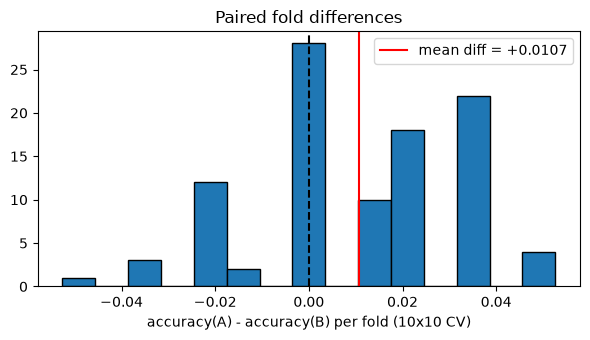

In [17]:
# (3) McNemar's test on a single hold-out split
Xa, Xh, ya, yh = train_test_split(Xb, yb, test_size=0.4, stratify=yb, random_state=1)
predA = A_model.fit(Xa, ya).predict(Xh); predB = B_model.fit(Xa, ya).predict(Xh)
cA, cB = predA == yh, predB == yh
n01, n10 = np.sum(~cA & cB), np.sum(cA & ~cB)
chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
p_mc = stats.chi2.sf(chi2, df=1)
p_exact = stats.binomtest(int(n10), int(n01 + n10), 0.5).pvalue if n01 + n10 > 0 else 1.0
print(f"hold-out acc A={cA.mean():.4f}, B={cB.mean():.4f}")
print(f"contingency: A wrong & B right = {n01}, A right & B wrong = {n10}")
print(f"McNemar chi2={chi2:.3f}, p={p_mc:.4f};  exact binomial p={p_exact:.4f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(dr, bins=15, edgecolor="k")
ax.axvline(0, c="k", ls="--"); ax.axvline(dr.mean(), c="r", label=f"mean diff = {dr.mean():+.4f}")
ax.set_xlabel("accuracy(A) - accuracy(B) per fold (10x10 CV)"); ax.legend(); ax.set_title("Paired fold differences")
plt.tight_layout(); plt.show()

## 9. Pitfalls & practical tips

- **Touch the test set once.** Every look at it that influences a decision (features, model, threshold) makes it a validation set.
- **Put every fitted transformation in a `Pipeline`**: scaling, imputation, encoding, feature selection, dimensionality reduction, resampling (use `imblearn` pipelines for the latter if available).
- **Split to mimic deployment**: group splits for repeated measurements per entity, forward-chaining for time series, stratification for small / imbalanced classification.
- **Report variability** (fold standard deviations, repeated CV), and remember naive CV standard errors are too small.
- **Reported "best CV score" of a search is optimistic.** Use nested CV (or a fresh test set) to report the performance of a tuned model.
- **Search on log scales** for scale hyperparameters ($C$, $\gamma$, $\alpha$, learning rates); prefer random search when there are more than two or three hyperparameters.
- **Choose the metric before looking at results**, and match it to the application (Lecture 03).
- **Deduplicate** data before splitting: near-duplicates across folds are a subtle form of leakage.
- For model comparison, prefer the corrected resampled $t$-test or Bayesian alternatives over the naive paired $t$-test; for many models / datasets use Friedman + post-hoc tests.

## 10. Exercises

**Exercise 1 (math).** For ridge regression (a linear smoother $\hat{\mathbf{y}} = H\mathbf{y}$ with $H = X(X^\top X + \lambda I)^{-1}X^\top$), prove the LOO identity $y_i - \hat f^{(-i)}(\mathbf{x}_i) = \frac{y_i - \hat y_i}{1-H_{ii}}$ using the Sherman–Morrison formula. Then verify it numerically on `load_diabetes`.

**Exercise 2 (coding).** Implement `stratified_kfold_indices(y, k, seed)` from scratch (assign the indices of each class round-robin to folds after shuffling). Check that each fold's class proportions match the global ones within one sample.

**Exercise 3 (coding).** Implement nested CV from scratch with two loops (outer `kfold_indices`, inner `kfold_indices` for a 1-D grid over $C$ of a scaled logistic regression) and compare with `cross_val_score(GridSearchCV(...))` on the breast cancer data.

**Exercise 4 (analysis).** Repeat the ESL leakage experiment of Section 6 for $k\in\{5, 20, 100, 1000\}$ selected features. Plot the leaky and the correct CV accuracy vs $k$ and explain the shape.

**Exercise 5 (simulation).** Estimate the type-I error of the naive paired $t$-test vs the corrected resampled $t$-test: draw two *identical* algorithms (e.g. the same logistic regression with two different random seeds for a random-feature subsample of 80%), run 10×10 CV on 100 random datasets from `make_classification`, and record how often $p<0.05$.

**Exercise 6 (math).** Explain why the variance of the $k$-fold CV estimate cannot be estimated unbiasedly from a single run, by writing $\operatorname{Var}(\widehat{\text{CV}})$ in terms of the per-sample error variance and the covariances within and across folds.

In [18]:
# Exercise 1 starter: closed-form LOO for ridge
def ridge_loo_residuals(X, y, lam):
    # TODO: compute H = X (X^T X + lam I)^{-1} X^T, then (y - H y) / (1 - diag(H)).
    return None

# Exercise 2 starter
def stratified_kfold_indices(y, k, seed=0):
    # TODO: for each class, shuffle its indices and deal them out to the k folds in turn.
    #       Return a list of (train_idx, val_idx) pairs like kfold_indices().
    return None

# Exercise 3 starter
def nested_cv_scratch(X, y, Cs, k_outer=5, k_inner=5, seed=0):
    # TODO: outer loop over kfold_indices(len(y), k_outer); inside, choose C by inner CV
    #       on the outer-training part only; refit and score on the outer-test fold.
    return None

print("stubs:", ridge_loo_residuals.__name__, stratified_kfold_indices.__name__, nested_cv_scratch.__name__)

stubs: ridge_loo_residuals stratified_kfold_indices nested_cv_scratch


## 11. Summary

- Training error is optimistic; validation error becomes optimistic once used for selection; only untouched test data gives an unbiased final estimate.
- $k$-fold CV estimates the error of a model trained on $\frac{k-1}{k}n$ points; $k=5$–$10$ is a good default, repeated CV reduces partition noise, and fold-based standard errors are too small.
- The splitting scheme must mimic deployment: **stratified** for classification, **grouped** for repeated entities, **forward-chaining** for time.
- **Validation curves** and **learning curves** diagnose bias vs variance and tell you whether more data, more capacity, or more regularization will help.
- Tune with grid / random search, and report the tuned model's performance with **nested CV**.
- **Leakage** (especially supervised feature selection outside CV) can make noise look predictive; `Pipeline` + `ColumnTransformer` make every data-dependent step fold-safe.
- Compare models with paired tests on identical folds, using the **Nadeau–Bengio correction**; McNemar's test compares two fitted models on one test set.

## Further reading

- James et al. — *ISLP*, Ch. 5 (Resampling methods).
- Hastie, Tibshirani, Friedman — *ESL*, Ch. 7 (Model assessment and selection), esp. §7.10 (cross-validation, "the wrong and right way").
- Murphy — *Probabilistic Machine Learning: An Introduction*, §4.5 and §5.4 (model selection).
- Géron — *Hands-On Machine Learning*, Ch. 2 (end-to-end project, pipelines) and Ch. 3.
- Kohavi (1995), "A study of cross-validation and bootstrap for accuracy estimation and model selection", *IJCAI*.
- Dietterich (1998), "Approximate statistical tests for comparing supervised classification learning algorithms", *Neural Computation*.
- Nadeau & Bengio (2003), "Inference for the generalization error", *Machine Learning*.
- Bengio & Grandvalet (2004), "No unbiased estimator of the variance of K-fold cross-validation", *JMLR*.
- Cawley & Talbot (2010), "On over-fitting in model selection and subsequent selection bias in performance evaluation", *JMLR*.
- Bergstra & Bengio (2012), "Random search for hyper-parameter optimization", *JMLR*.
- Demšar (2006), "Statistical comparisons of classifiers over multiple data sets", *JMLR*.
- Kaufman et al. (2012), "Leakage in data mining: formulation, detection, and avoidance", *ACM TKDD*.